# Fake News Classification & Analysis

**GDG on Campus – ENSAK · Educational portfolio edition**

This notebook presents a reproducible edition of the submitted workshop scripts. It demonstrates data analysis and machine learning on a small, template-style dataset. It is not a fact-checking tool. See `originals/` for the submitted material and the README for the changes made in this edition.

## 1. Load and inspect the supplied data

The default CSV has 800 labeled articles and just 10 distinct bodies. Labels are workshop labels, not independently verified facts.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.analysis import load_data, run_analysis, TEXT_FEATURES

df = load_data(ROOT / "data" / "fake_news.csv")
display(df.head())
display(df["Etiquette"].value_counts().rename("articles").to_frame())
print("Distinct article bodies:", df["Corps_Textee"].nunique())

,ID_Article,Title,Corps_Textee,URL_Source,Nb_Partages,Etiquette
0,1,New Park Opens in City 77,"According to recent reports, the situation is ...",nytimes.com,186,Real
1,2,SHOCKING REVELATION!!! 79,This is a shocking revelation that they don't ...,clickme.xyz,450,Fake
2,3,SHOCKING REVELATION!!! 9,This is a shocking revelation that they don't ...,dailybuzz.net,13048,Fake
3,4,Election Results Announced 10,"According to recent reports, the situation is ...",bbc.com,1967,Real
4,5,New Park Opens in City 2,"According to recent reports, the situation is ...",nytimes.com,315,Real


,articles
Etiquette,
Real,475
Fake,325


Distinct article bodies: 10


## 2. Run the reproducible analysis

The classifier uses eight numeric features: headline and body statistics, a simple clickbait heuristic, and sharing activity. An 80/20 stratified split uses seed 42; the share-clipping threshold is fitted only on training data. Topic clustering uses TF-IDF and K-Means separately, as an exploratory step.

In [2]:
metrics = run_analysis(ROOT / "data" / "fake_news.csv", ROOT / "results")
display(pd.DataFrame(metrics["classification"]["classification_report"]).T)

Educational holdout results
Dataset: 800 articles; train: 640; test: 160
Accuracy: 1.0000
Fake-class F1: 1.0000
Majority baseline accuracy: 0.5938

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00        95
        Fake       1.00      1.00      1.00        65

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160

Sharing regression MAE: 12823.09
Median baseline MAE: 8001.54

Template-style workshop data with overlapping text across the random split. Metrics are educational, not real-world validation.



,precision,recall,f1-score,support
Real,1.0,1.0,1.0,95.0
Fake,1.0,1.0,1.0,65.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,160.0
weighted avg,1.0,1.0,1.0,160.0


## 3. Inspect classification results

These charts show what the model learned on this workshop dataset. Repeated text templates occur in both train and test; high scores do not establish generalization to authentic news.

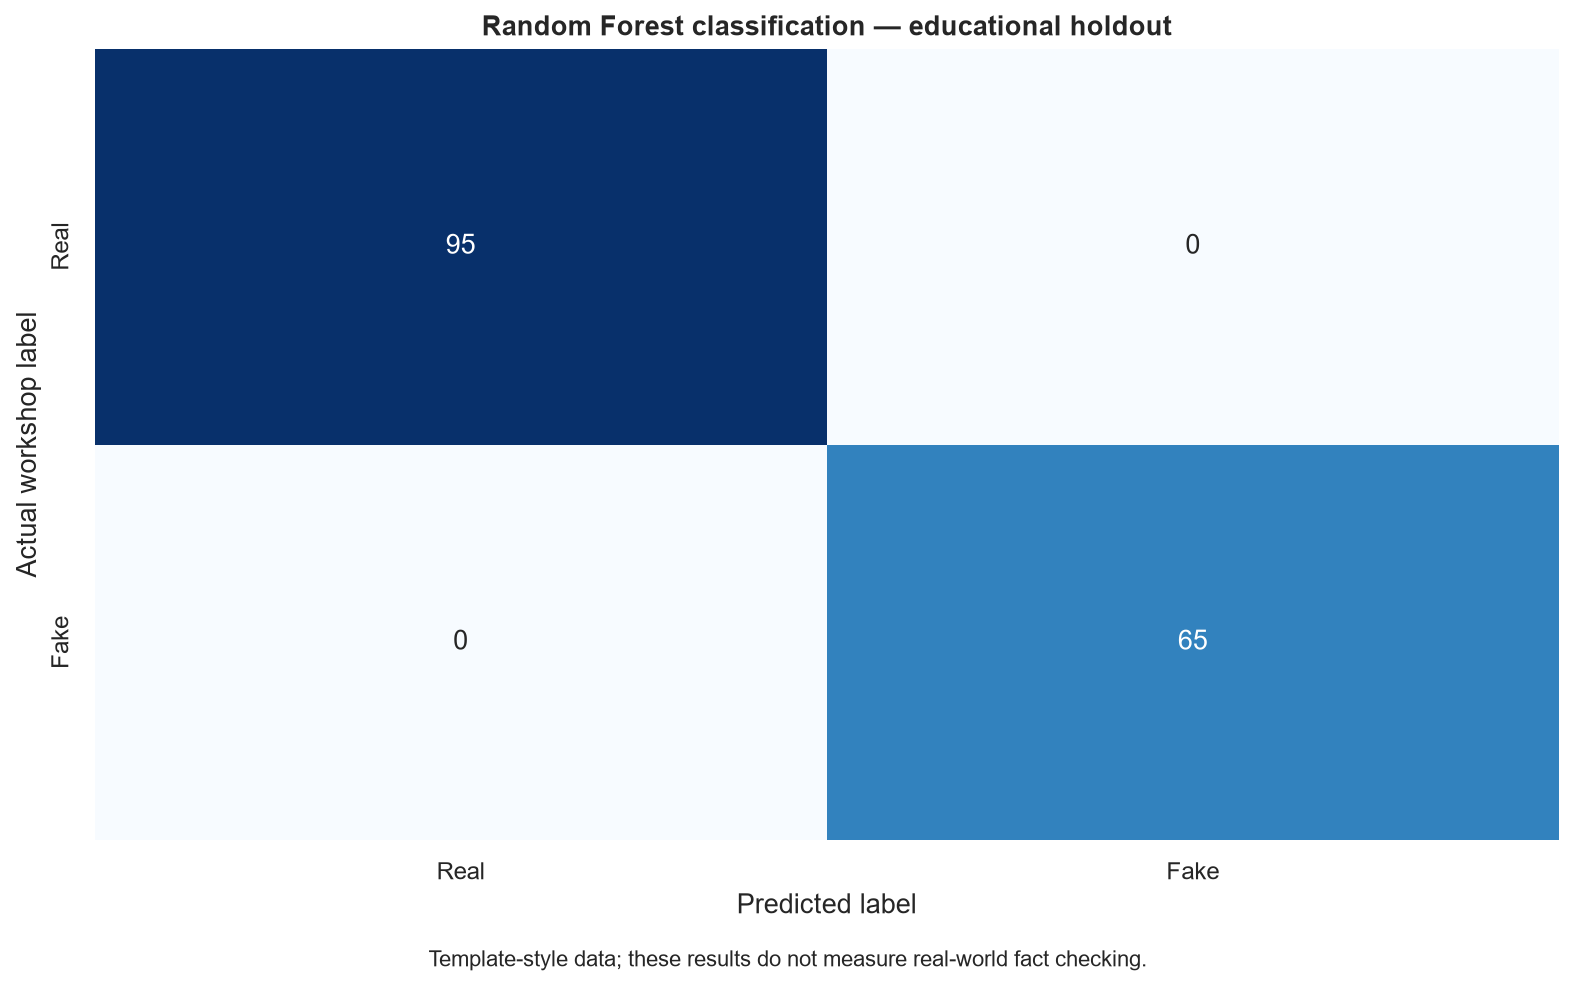

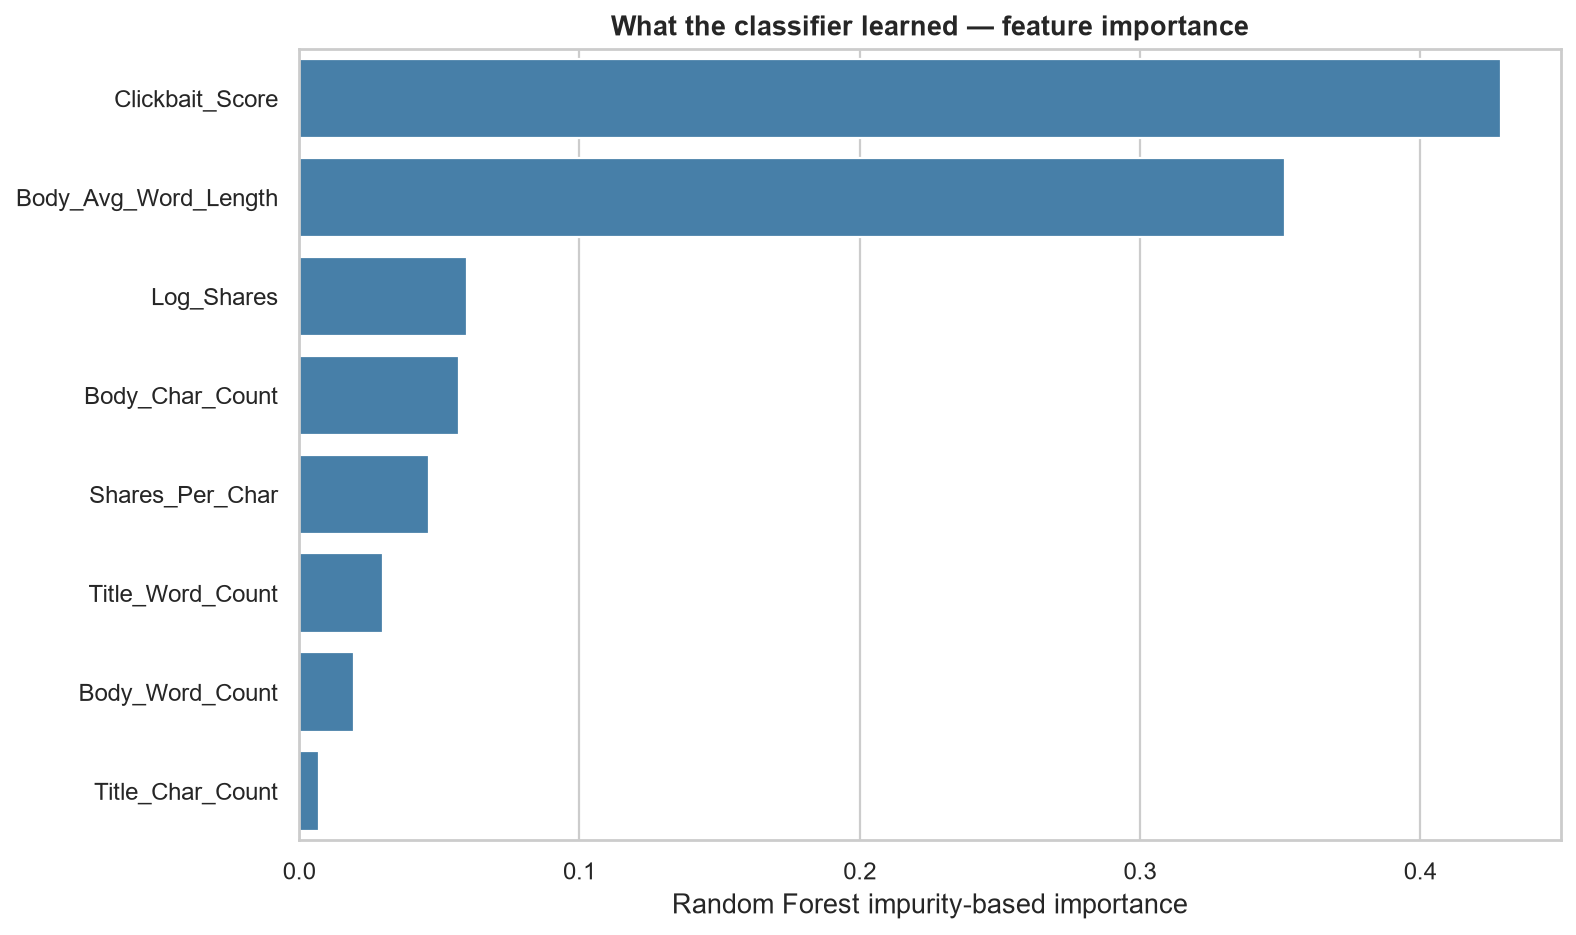

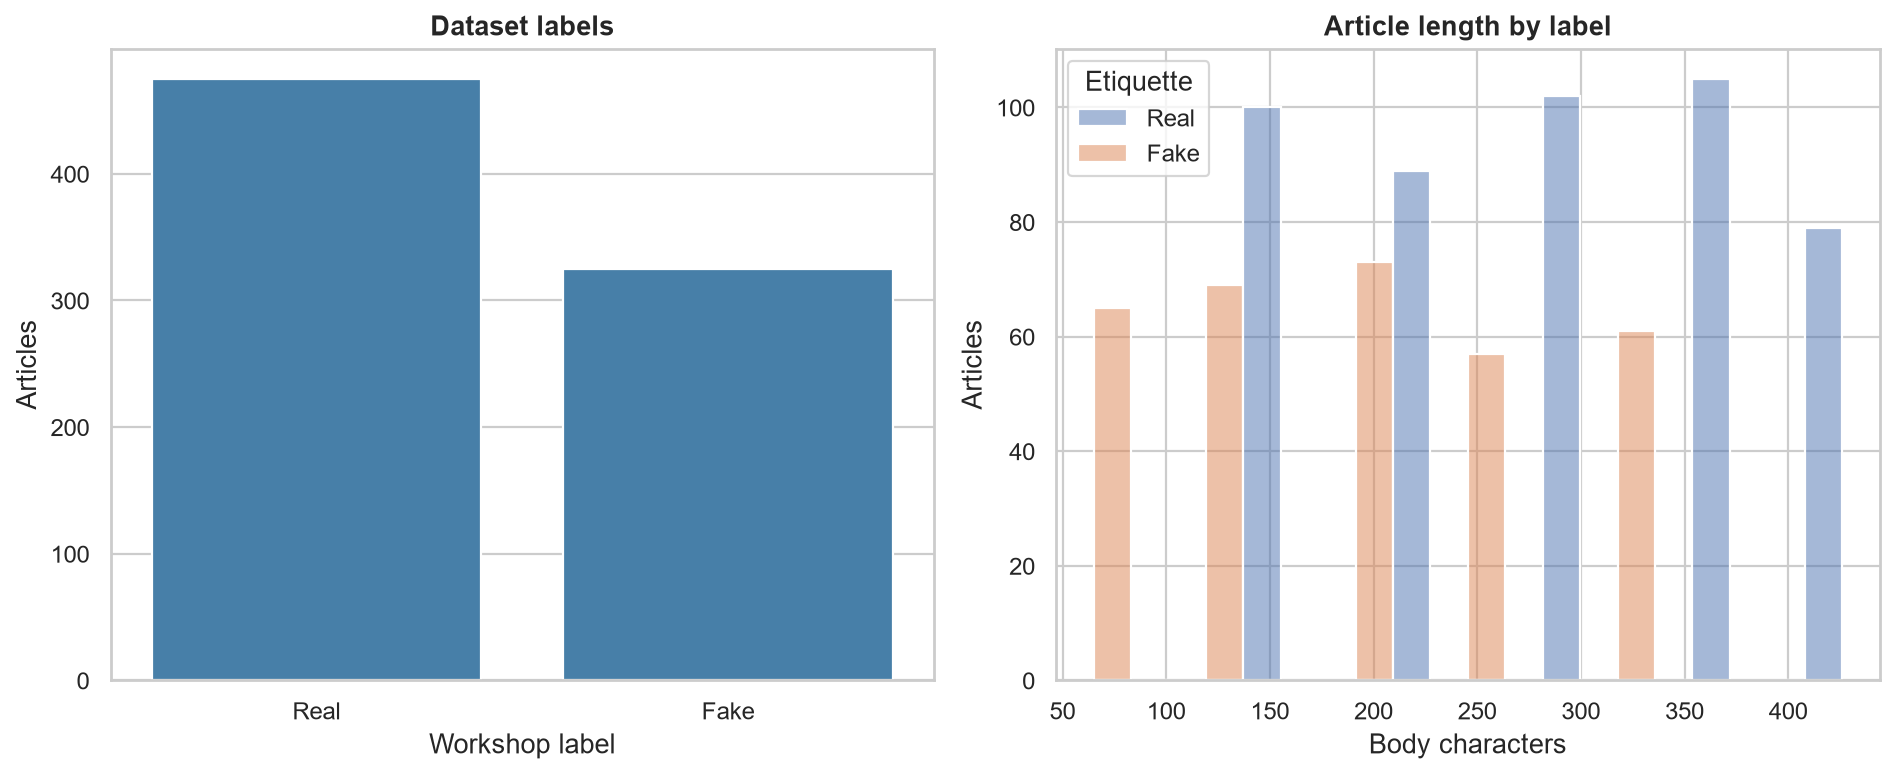

In [3]:
display(Image(filename=str(ROOT / "results" / "confusion_matrix.png")))
display(Image(filename=str(ROOT / "results" / "feature_importance.png")))
display(Image(filename=str(ROOT / "results" / "dataset_overview.png")))

## 4. Explore text groups and sharing patterns

Text clusters are arbitrary groups, not verified news topics. The short-text/high-sharing rule is a heuristic; article-level sharing counts cannot establish bot activity.

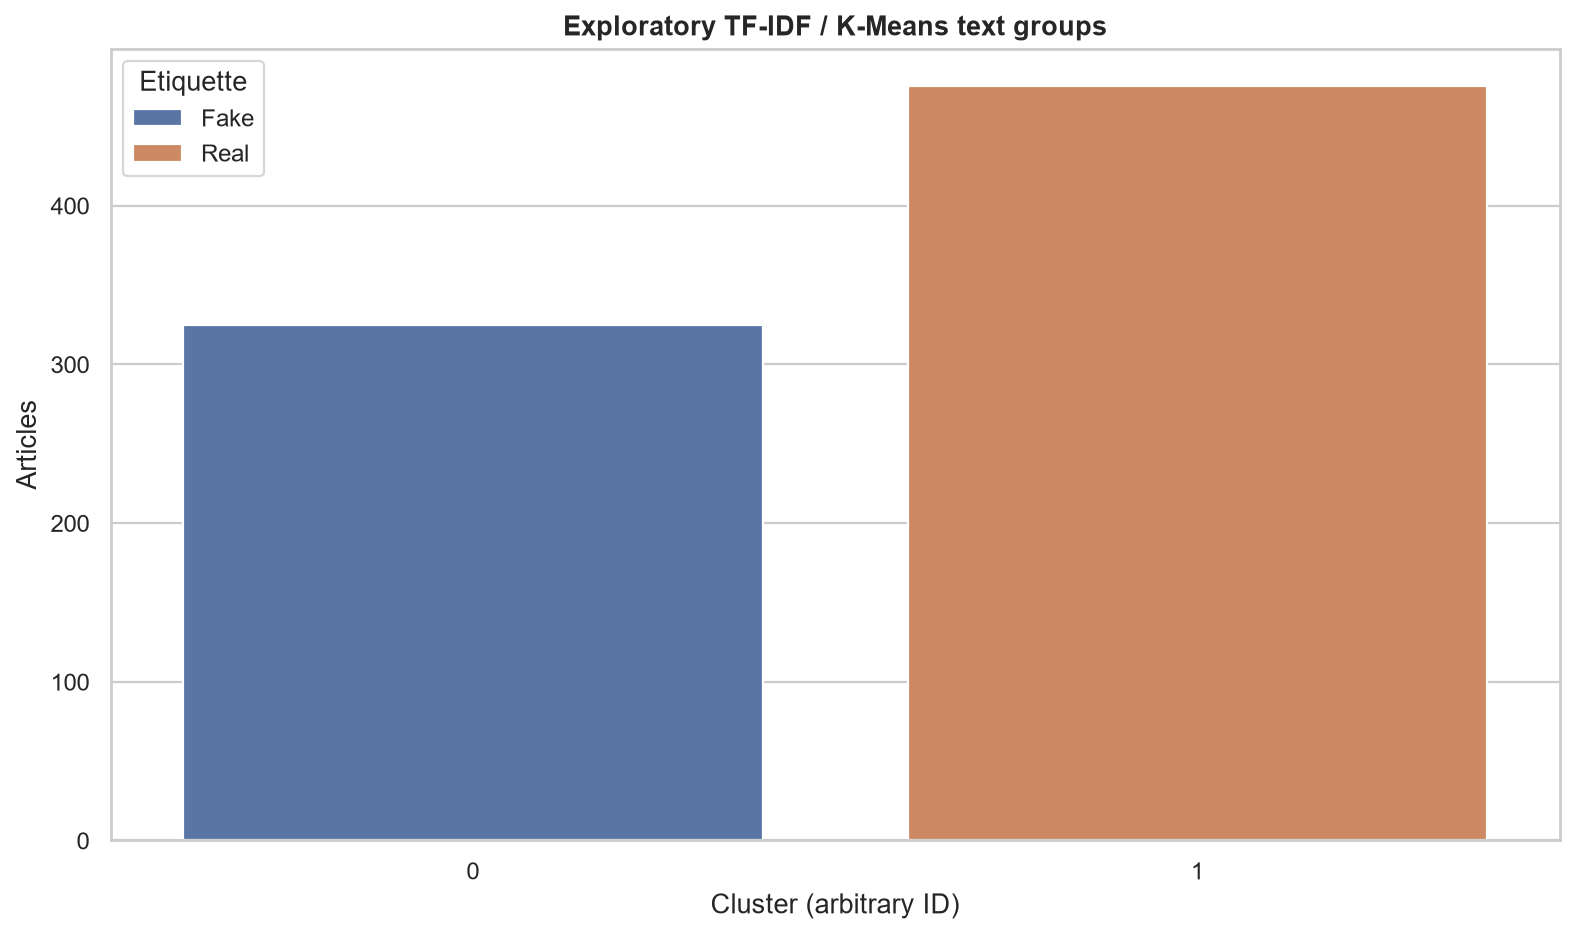

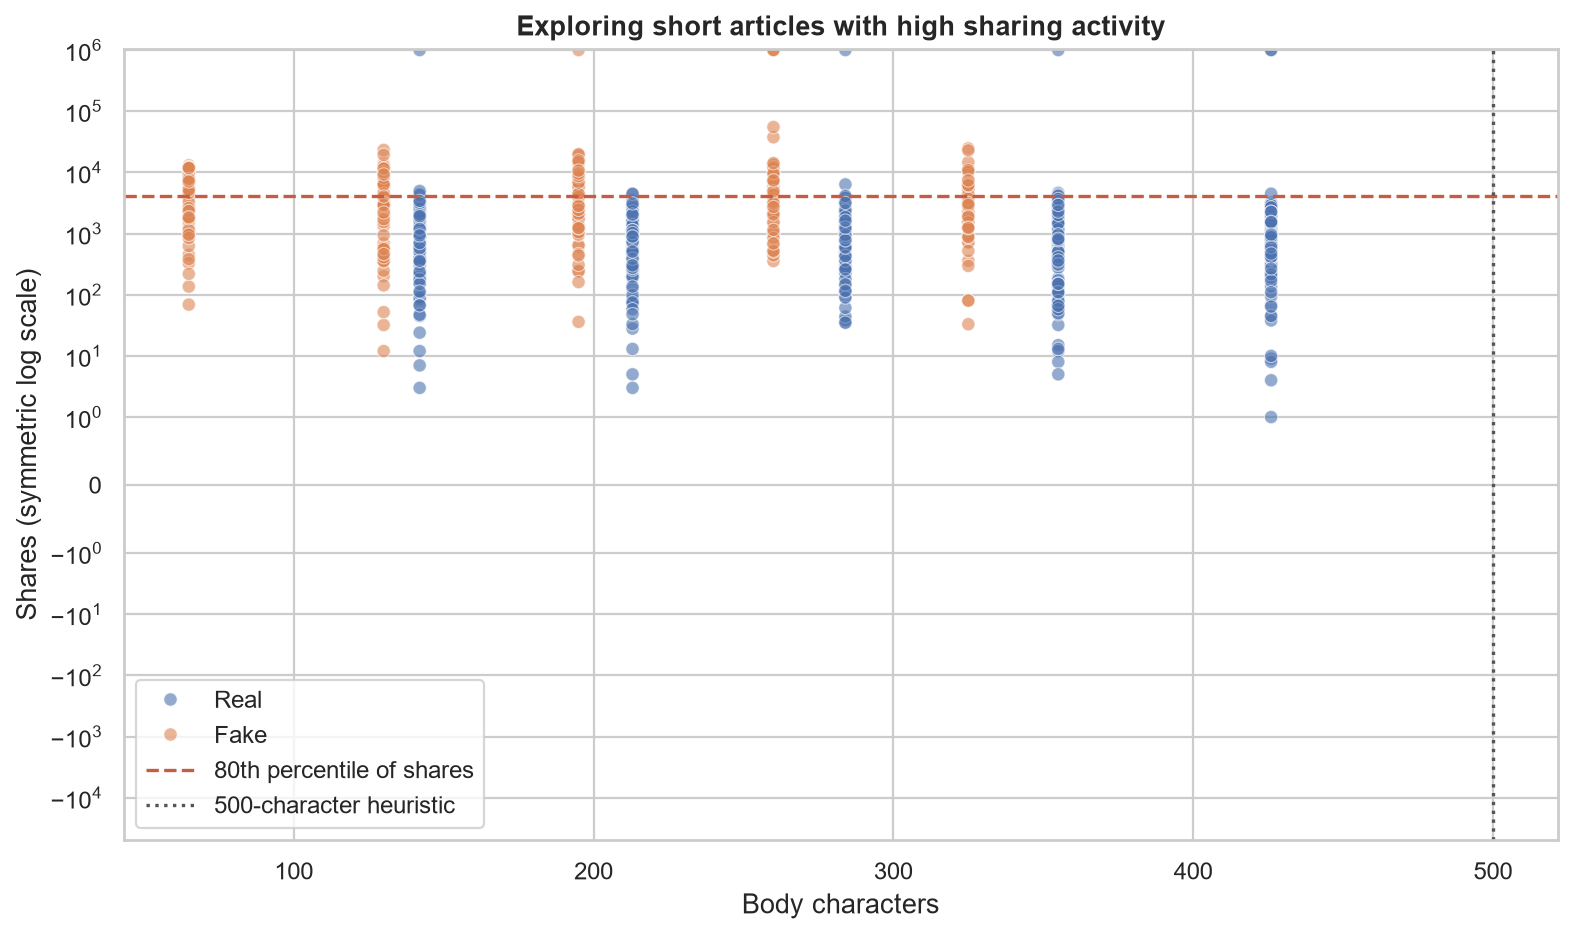

Cluster keywords: {'0': ['want', 'shocking', 'revelation', 'don', 'know'], '1': ['situation', 'recent', 'reports', 'according', 'expected', 'developing']}


In [4]:
display(Image(filename=str(ROOT / "results" / "text_clusters.png")))
display(Image(filename=str(ROOT / "results" / "sharing_patterns.png")))
print("Cluster keywords:", metrics["exploration"]["cluster_keywords"])

## 5. Sharing regression without target leakage

Unlike the original experiment, this version excludes shares per character and log shares when predicting the share count. It compares the Random Forest with a median baseline using the original uncapped target. This is retrospective analysis, not a validated forecast.

In [5]:
display(pd.DataFrame([metrics["sharing_regression"]]).drop(columns=["features"]))
print("Regression inputs:", TEXT_FEATURES)

,mae,median_baseline_mae,target,note
0,12823.08623,8001.54375,Uncapped Nb_Partages,Exploratory retrospective regression; not vali...


Regression inputs: ['Title_Word_Count', 'Title_Char_Count', 'Body_Word_Count', 'Body_Char_Count', 'Body_Avg_Word_Length', 'Clickbait_Score']


## 6. What would improve this project?

- Use a documented dataset of independently labeled real articles.
- Evaluate with source, time, or text-family holdouts to reduce overlap.
- Compare text-only baselines with the metadata-based classifier.
- Audit errors and potential source or style shortcuts.
- Establish provenance and redistribution terms for any new dataset.

The main result of this workshop is a complete, inspectable learning workflow, not evidence that misinformation can be reliably detected from style alone.